In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

"""Backend: pytorch"""
import torch

# FNO functions
import sampler

from scipy.interpolate import interp1d
from scipy.interpolate import griddata 

import warnings
from tqdm import tqdm
import time

In [2]:
%cd /home/jw3275/Characteristics-Net

import utils

%cd /home/jw3275/neuraloperator/scripts/fno_inviscid

/home/jw3275/Characteristics-Net
/home/jw3275/neuraloperator/scripts/fno_inviscid


In [3]:
%cd /home/jw3275/neuraloperator

from config.burgers_pino_config import Default
from neuralop import get_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = Default()
config = config.to_dict()

model = get_model(config).to(device)


/home/jw3275/neuraloperator


In [4]:
import torch
import neuralop.layers.spectral_convolution as sc

torch.serialization.add_safe_globals([sc.SpectralConv])
torch.serialization.add_safe_globals([torch._C._nn.gelu])


In [5]:
state_dict = torch.load(
    "/home/jw3275/neuraloperator/scripts/pino_heat_burgers_v_01_last_model_eqn_1_ic_10_res_100_modified_ite_10000.pt",
    map_location=device,
    weights_only=False
)

model.load_state_dict(state_dict)
model.eval()

print("Model loaded successfully!")


Model loaded successfully!


In [6]:
import numpy as np
import torch

def fno_predict_u(model, v_branch, x_grid, t_grid, device):
    """
    v_branch: (Nx,)  initial condition
    x_grid:   (Nx,)
    t_grid:   (Nt,)
    returns: u_pred (Nt, Nx)
    """
    model.eval()

    with torch.no_grad():
        Nx_eval = x_grid.shape[0]
        Nt_eval = t_grid.shape[0]

        # convert to torch
        v = torch.tensor(v_branch, dtype=torch.float32, device=device)
        x = torch.tensor(x_grid,    dtype=torch.float32, device=device)
        t = torch.tensor(t_grid,    dtype=torch.float32, device=device)

        print("v shape: ", v.shape)
        print("x shape: ", x.shape)
        print("t shape: ", t.shape)

        # tile along time/space to form grids
        v_tile = v.unsqueeze(0).unsqueeze(0).repeat(1, Nt_eval, 1)   # (1, Nt, Nx)
        x_tile = x.unsqueeze(0).unsqueeze(0).repeat(1, Nt_eval, 1)
        t_tile = t[None, :, None].repeat(1, 1, Nx_eval)

        print("v tile shape: ", v_tile.shape)
        print("x tile shape: ", x_tile.shape)
        print("t tile shape: ", t_tile.shape)

        # stack into input tensor
        inp = torch.stack([v_tile, t_tile, x_tile], dim=1)          # (1, 3, Nt, Nx)

        u_pred = model(torch.stack([v_tile]))                                         # (1, 1, Nt, Nx)
        u_pred = u_pred[0, 0].cpu().numpy()

    return u_pred


Ground Truth
[solve_heat_burgers] dx=1.000e-02, dt=4.498e-04, steps=2223, dt_diff=5.000e-04


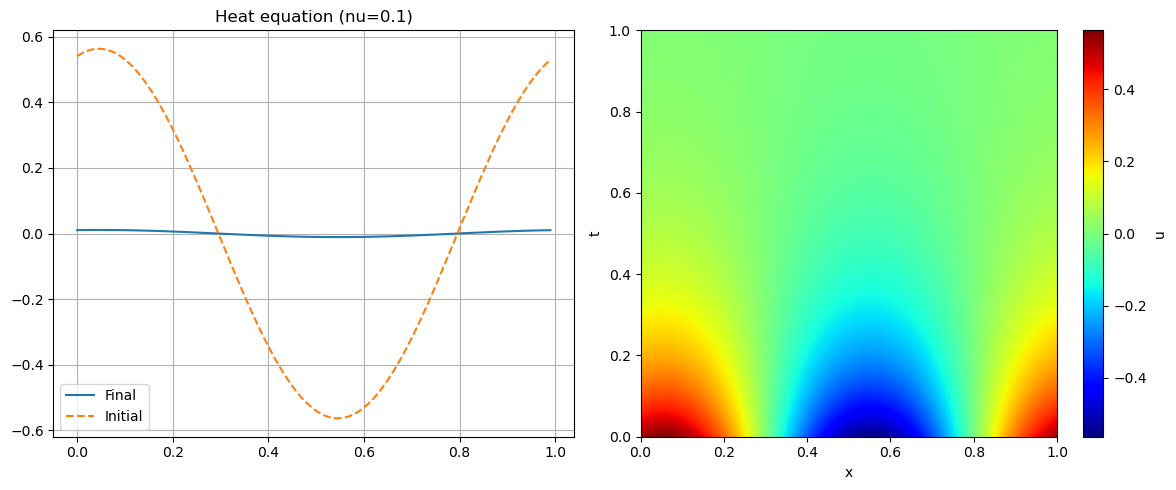

Predict
v shape:  torch.Size([100])
x shape:  torch.Size([100])
t shape:  torch.Size([112])
v tile shape:  torch.Size([1, 112, 100])
x tile shape:  torch.Size([1, 112, 100])
t tile shape:  torch.Size([1, 112, 100])


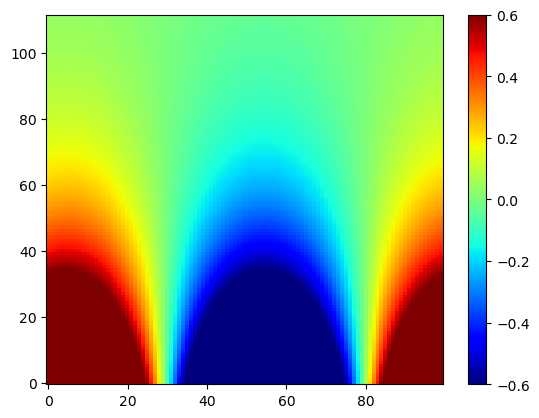

L2-relative erros:  2.647656381039058
L1-relative erros:  2.6230993499742405


In [7]:
# Example usage

print("Ground Truth")
ic = lambda x : np.sin(2*np.pi*x)+np.cos(2*np.pi*x+np.ones_like(x))
#u_0 = utils.numericals.solve_inviscid_burgers(ic, t_max=1, Nx=256*2, Nt=5000, plot=True) 


# Viscosity should match the PDE you trained PINO on (nu=0.1 here)
u_0 = utils.numericals.solve_heat_burgers_01(
    ic,
    nu=0.1,          # match the nu in your BurgersEqnLoss
    x_max=1.0,
    t_max=1.0,
    Nx=100,        
    Nt=2000,         # target; function may internally increase steps for stability
    CFL=0.4,
    plot=True,
)

# Compute L2-relative error
u_0 = np.array(u_0)[::20, :]   # shape: (Nt', 256)
Nt, Nx = u_0.shape


# Compute L2-relative error
#u_0 = np.array(u_0)[::20, ::2]
#Nt, Nx = u_0.shape

print("Predict")

#n_pts_edge = 256
#eval_pts = np.linspace(0, 1, num=n_pts_edge, endpoint=False)
#v_branch = ic(eval_pts)

# grid of predictions

#x_grid = np.linspace(0, 1.0, num=Nx)
#t_grid = np.linspace(0, 1.0, num=Nt)

#x_grid = np.linspace(0, 1.0, num=Nx, endpoint=False)
#t_grid = np.linspace(0, 1.0, num=Nt, endpoint=True)


Nx = 100
Nt = u_0.shape[0]

x_grid = np.linspace(0, 1.0, num=Nx, endpoint=False)
t_grid = np.linspace(0, 1.0, num=Nt, endpoint=True)

v_branch = ic(x_grid)   # <-- FIX: match Nx



y_preds = fno_predict_u(model, v_branch, x_grid, t_grid, device)

# y = np.asarray(y_preds)
# if y.ndim == 2 and y.shape[1] > 1:
#     y = y[:, 1]  # u channel
# y_pred = y.reshape(n_time, n_curves)

plt.figure()
plt.imshow(y_preds, origin="lower", aspect="auto", cmap="jet", vmin=-0.6, vmax=0.6)
plt.colorbar()
plt.show()

print("L2-relative erros: ", utils.metrics.major_err(u_0-y_preds, u_0, 0.99))
print("L1-relative erros: ", utils.metrics.major_err(u_0-y_preds, u_0, 0.99, ord=1))

Ground Truth
[solve_heat_burgers] dx=1.000e-02, dt=4.498e-04, steps=2223, dt_diff=5.000e-04


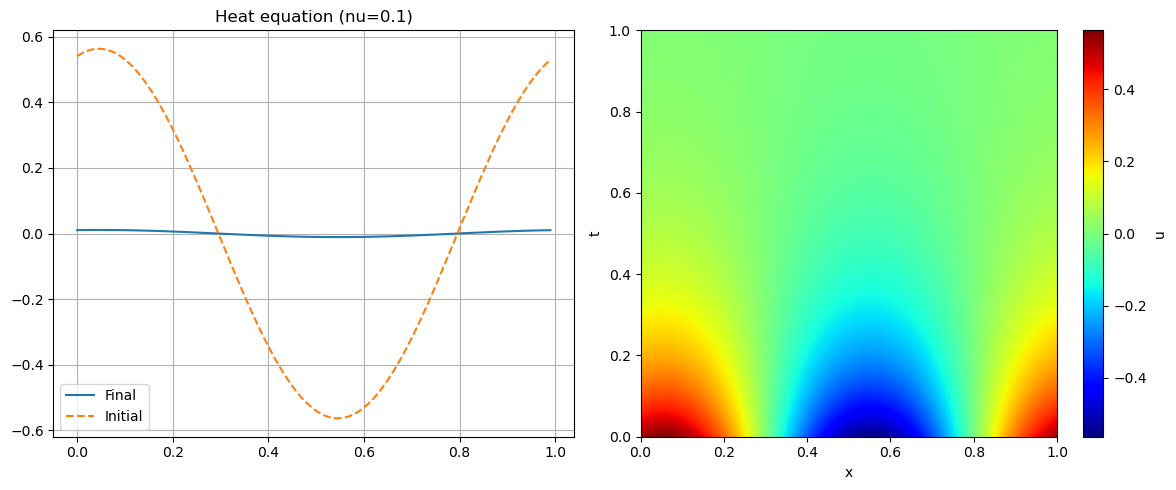

u_ref shape: (100, 100)
v shape:  torch.Size([100])
x shape:  torch.Size([100])
t shape:  torch.Size([100])
v tile shape:  torch.Size([1, 100, 100])
x tile shape:  torch.Size([1, 100, 100])
t tile shape:  torch.Size([1, 100, 100])
[solve_heat_burgers] dx=1.000e-02, dt=4.498e-04, steps=2223, dt_diff=5.000e-04
u_num shape: (100, 100)


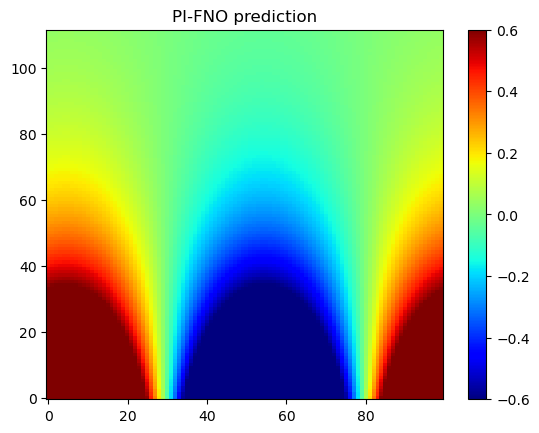

L2-relative erros:  2.647656381039058
L1-relative erros:  2.6230993499742405
Numerical L2-rel: nan
PI-FNO L2-rel: 2.607224619157379


/home/jw3275/Characteristics-Net/utils/metrics.py:8: RuntimeWarning: invalid value encountered in scalar divide
  return np.linalg.norm(arr1[mask], ord=ord) / np.linalg.norm(arr2[mask], ord=ord)


In [8]:
# Example usage

print("Ground Truth")
ic = lambda x : np.sin(2*np.pi*x)+np.cos(2*np.pi*x+np.ones_like(x))
#u_0 = utils.numericals.solve_inviscid_burgers(ic, t_max=1, Nx=256*2, Nt=5000, plot=True) 

Nx_ref = 100
Nt_ref = 2000

# Viscosity should match the PDE you trained PINO on (nu=0.1 here)
u_ref_high = utils.numericals.solve_heat_burgers_01(
    ic,
    nu=0.1,          # match the nu in your BurgersEqnLoss
    x_max=1.0,
    t_max=1.0,
    Nx=Nx_ref,        
    Nt=Nt_ref,         # target; function may internally increase steps for stability
    CFL=0.4,
    plot=True,
)

# Compute L2-relative error
u_ref_high = np.array(u_ref_high)
Nt_ref_actual, Nx = u_ref_high.shape


# Compute L2-relative error
#u_0 = np.array(u_0)[::20, ::2]
#Nt, Nx = u_0.shape

Nt_pino = 100

stride_ref = Nt_ref_actual // Nt_pino
u_ref = u_ref_high[::stride_ref, :][:Nt_pino, :]

print("u_ref shape:", u_ref.shape)   # (100,100)

#n_pts_edge = 256
#eval_pts = np.linspace(0, 1, num=n_pts_edge, endpoint=False)
#v_branch = ic(eval_pts)

# grid of predictions

#x_grid = np.linspace(0, 1.0, num=Nx)
#t_grid = np.linspace(0, 1.0, num=Nt)

#x_grid = np.linspace(0, 1.0, num=Nx, endpoint=False)
#t_grid = np.linspace(0, 1.0, num=Nt, endpoint=True)


Nx = 100
Nt = 100


x_grid = np.linspace(0, 1.0, num=Nx, endpoint=False)
t_grid = np.linspace(0, 1.0, num=Nt, endpoint=True)

v_branch = ic(x_grid)   # <-- FIX: match Nx

u_pino = fno_predict_u(model, v_branch, x_grid, t_grid, device)

#---------

u_num_full = utils.numericals.solve_heat_burgers_01(
    ic,
    nu=0.1,
    x_max=1.0,
    t_max=1.0,
    Nx=100,
    Nt=100,
    CFL=0.4,
    plot=False,
)

u_num_full = np.array(u_num_full)
Nt_num_actual = u_num_full.shape[0]

stride_num = Nt_num_actual // Nt_pino
u_num = u_num_full[::stride_num, :][:Nt_pino, :]

print("u_num shape:", u_num.shape)   # (100,100)

# y = np.asarray(y_preds)
# if y.ndim == 2 and y.shape[1] > 1:
#     y = y[:, 1]  # u channel
# y_pred = y.reshape(n_time, n_curves)

plt.figure()
plt.imshow(y_preds, origin="lower", aspect="auto", cmap="jet", vmin=-0.6, vmax=0.6)
plt.colorbar()
plt.title("PI-FNO prediction")
plt.show()

print("L2-relative erros: ", utils.metrics.major_err(u_0-y_preds, u_0, 0.99))
print("L1-relative erros: ", utils.metrics.major_err(u_0-y_preds, u_0, 0.99, ord=1))


print("Numerical L2-rel:",
      utils.metrics.major_err(u_num - u_ref, u_ref, 0.99))

print("PI-FNO L2-rel:",
      utils.metrics.major_err(u_pino - u_ref, u_ref, 0.99))


In [9]:
T_cut = 30   # e.g. first 30 time steps

num_err_early = utils.metrics.major_err(
    u_num[:T_cut] - u_ref[:T_cut],
    u_ref[:T_cut],
    0.99
)

pino_err_early = utils.metrics.major_err(
    u_pino[:T_cut] - u_ref[:T_cut],
    u_ref[:T_cut],
    0.99
)

print("Numerical L2-rel (early):", num_err_early)
print("PI-FNO L2-rel (early):", pino_err_early)


Numerical L2-rel (early): nan
PI-FNO L2-rel (early): 2.6277553928046014


In [10]:
abs_err_num = np.linalg.norm(u_num - u_ref)
abs_err_pino = np.linalg.norm(u_pino - u_ref)

print("Numerical L2 (absolute):", abs_err_num)
print("PI-FNO L2 (absolute):", abs_err_pino)


Numerical L2 (absolute): 0.0
PI-FNO L2 (absolute): 37.979045824127326


In [11]:
ic_norm = np.linalg.norm(u_ref[0])

pino_err_ic_scaled = np.linalg.norm(u_pino - u_ref) / ic_norm
num_err_ic_scaled  = np.linalg.norm(u_num - u_ref) / ic_norm

print("Numerical IC-scaled L2:", num_err_ic_scaled)
print("PI-FNO IC-scaled L2:", pino_err_ic_scaled)


Numerical IC-scaled L2: 0.0
PI-FNO IC-scaled L2: 9.538710509403831


In [14]:
u_true = u_0          # (Nt, Nx)
u_pred = y_preds      # (Nt, Nx)

abs_l2 = np.linalg.norm(u_pred - u_true)
print("Absolute L2:", abs_l2)


Absolute L2: 40.29001877880402


In [15]:
u_true = u_0          # (Nt, Nx)
u_pred = y_preds      # (Nt, Nx)

ic_norm = np.linalg.norm(u_true[0])   # t=0 slice
rel_l2_ic = np.linalg.norm(u_pred - u_true) / ic_norm
print("Relative L2 (IC scale):", rel_l2_ic)


Relative L2 (IC scale): 10.119127987815537


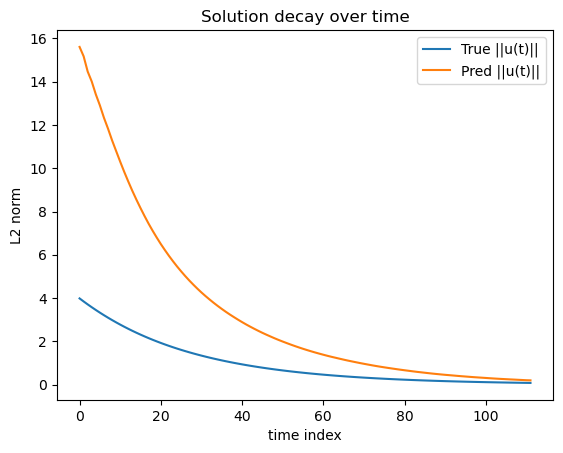

In [16]:
u_true = u_0          # (Nt, Nx)
u_pred = y_preds      # (Nt, Nx)

true_norm_t = np.linalg.norm(u_true, axis=1)
pred_norm_t = np.linalg.norm(u_pred, axis=1)

plt.plot(true_norm_t, label="True ||u(t)||")
plt.plot(pred_norm_t, label="Pred ||u(t)||")
plt.xlabel("time index")
plt.ylabel("L2 norm")
plt.legend()
plt.title("Solution decay over time")
plt.show()


In [17]:
u0_norm = np.linalg.norm(u_0[0])
rel_over_u0 = np.linalg.norm((u_0 - y_preds).ravel()) / (u0_norm * np.sqrt(u_0.size / u_0.shape[1]))
print("rel L2 wrt IC scale of nu=0.1:", rel_over_u0)


rel L2 wrt IC scale of nu=0.1: 0.9561677193069054


median rel of nu=0.1: 2.0321948021026515 max rel of nu=0.1: 2.9526105109425442


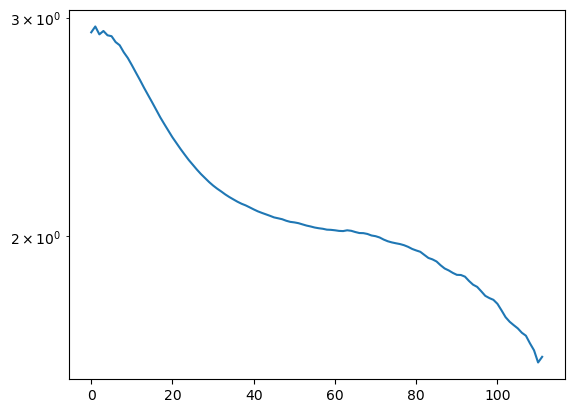

In [18]:
rel_t = np.linalg.norm(u_0 - y_preds, axis=1) / (np.linalg.norm(u_0, axis=1) + 1e-12)
print("median rel of nu=0.1:", np.median(rel_t), "max rel of nu=0.1:", rel_t.max())
plt.plot(rel_t); plt.yscale("log"); plt.show()


In [15]:
u_true = u_0          # (Nt, Nx)
u_pred = y_preds      # (Nt, Nx)

den = np.linalg.norm(u_true.ravel())
num = np.linalg.norm((u_true - u_pred).ravel())
print("abs L2 of nu=0.1:", num, "true L2 of nu=0.1:", den, "rel L2 of nu=0.1:", num/den)
print("u_true min/max of nu=0.1:", u_true.min(), u_true.max(), "std of nu=0.1:", u_true.std())
print("u_pred min/max of nu=0.1:", u_pred.min(), u_pred.max(), "std of nu=0.1:", u_pred.std())


abs L2 of nu=0.1: 331.11898231895236 true L2 of nu=0.1: 128.83851100015687 rel L2 of nu=0.1: 2.5700311168494427
u_true min/max of nu=0.1: -0.5630556139848517 0.5630556139848518 std of nu=0.1: 0.14066546741144384
u_pred min/max of nu=0.1: -2.1182332 2.1068053 std of nu=0.1: 0.49934554


In [13]:
print("true std of nu=0.1:", u_true.std(), "pred std of nu=0.1:", u_pred.std())


true std of nu=0.1: 0.14066546741144384 pred std of nu=0.1: 0.51780194


In [17]:
# --- Ground truth ---
u_hist = np.array(utils.numericals.solve_viscous_burgers_01(
    ic,
    nu=0.1,
    x_max=1.0, t_max=1.0,
    Nx=256,
    Nt=5000,
    CFL=0.4,
    plot=False,
))  # (n_steps+1, Nx) hopefully

t_hist = np.linspace(0.0, 1.0, u_hist.shape[0])

stride = 20
u_0 = u_hist[::stride]
t_grid = t_hist[::stride]
Nt, Nx = u_0.shape

# --- Prediction grids (match periodic [0,1)) ---
x_grid = np.linspace(0.0, 1.0, Nx, endpoint=False)
eval_pts = x_grid.copy()
v_branch = ic(eval_pts)

y_preds = fno_predict_u(model, v_branch, x_grid, t_grid, device)  # should be (Nt, Nx)

# --- Errors ---
err = u_0 - y_preds
print("abs L2:", np.linalg.norm(err))
print("rel L2:", np.linalg.norm(err) / (np.linalg.norm(u_0) + 1e-12))

print("major rel L2:", utils.metrics.major_err(err, u_0, 0.99))
print("major rel L1:", utils.metrics.major_err(err, u_0, 0.99, ord=1))


[solve_viscous_burgers] dx=3.906e-03, dt=1.526e-05, steps=65536, dt_conv=2.775e-03, dt_diff=7.629e-05
v shape:  torch.Size([256])
x shape:  torch.Size([256])
t shape:  torch.Size([3277])
v tile shape:  torch.Size([1, 3277, 256])
x tile shape:  torch.Size([1, 3277, 256])
t tile shape:  torch.Size([1, 3277, 256])
abs L2: 331.11898231895236
rel L2: 2.5700311168494228
major rel L2: 2.5321662440471266
major rel L1: 2.3193081054284526


In [ ]:
import torch
import numpy as np

def fno_predict_u(model, v_branch, Nt, device):
    """
    v_branch: (Nx,) initial condition sampled on x in [0,1) (endpoint=False)
    Nt: number of time points you want (must match training/eval resolution)
    returns: (Nt, Nx)
    """
    model.eval()
    with torch.no_grad():
        v = torch.tensor(v_branch, dtype=torch.float32, device=device)  # (Nx,)
        Nx = v.shape[0]

        # input must be (B, C=1, Nt, Nx)
        inp = v[None, None, None, :].repeat(1, 1, Nt, 1)  # (1,1,Nt,Nx)

        out = model(inp)          # (1,1,Nt,Nx)  coords are appended internally
        u_pred = out[0, 0].cpu().numpy()

    return u_pred


In [ ]:
import numpy as np

def solve_viscous_burgers_snapshots(
    ic,
    nu=1e-1,
    x_max=1.0,
    t_max=1.0,
    Nx=256,
    Nt_out=100,        # <-- exactly 100
    CFL=0.4,
    safety=0.2,
):
    """
    Solve u_t + (1/2 u^2)_x = nu u_xx on [0, x_max) periodic
    and return snapshots on save_times = linspace(0, t_max, Nt_out) (endpoint True).

    Returns:
      x: (Nx,) grid on [0,1) endpoint=False
      save_times: (Nt_out,)
      snapshots: (Nt_out, Nx)
    """
    x = np.linspace(0.0, x_max, Nx, endpoint=False)
    dx = x[1] - x[0]

    u = ic(x).astype(np.float64)

    # stable dt based on current u amplitude + diffusion
    max_u = max(np.max(np.abs(u)), 1e-8)
    dt_conv = CFL * dx / max_u
    dt_diff = 0.5 * dx * dx / max(nu, 1e-12)
    dt_base = min(dt_conv, dt_diff, t_max / max(Nt_out - 1, 1))
    dt = safety * dt_base

    n_steps = int(np.ceil(t_max / dt))
    dt = t_max / n_steps  # hit t_max exactly

    print(
        f"[solver] dx={dx:.3e}, dt={dt:.3e}, steps={n_steps}, "
        f"dt_conv={dt_conv:.3e}, dt_diff={dt_diff:.3e}"
    )

    save_times = np.linspace(0.0, t_max, Nt_out, endpoint=True)
    snapshots = np.empty((Nt_out, Nx), dtype=np.float64)
    snapshots[0] = u.copy()

    t = 0.0
    save_idx = 1

    for step in range(n_steps):
        u_prev = u

        # periodic neighbors
        u_right = np.roll(u_prev, -1)
        u_left  = np.roll(u_prev,  1)

        # flux f(u)=0.5 u^2
        f = 0.5 * u_prev**2
        f_right = np.roll(f, -1)

        # LLF wave speed
        a = np.maximum(np.abs(u_prev), np.abs(u_right))

        # LLF flux
        F_iphalf = 0.5 * (f + f_right) - 0.5 * a * (u_right - u_prev)
        F_imhalf = np.roll(F_iphalf, 1)

        convection = -(F_iphalf - F_imhalf) / dx
        u_xx = (u_right - 2.0 * u_prev + u_left) / (dx * dx)
        diffusion = nu * u_xx

        u = u_prev + dt * (convection + diffusion)
        t += dt

        if not np.all(np.isfinite(u)):
            raise RuntimeError(f"Non-finite at step {step}, t={t:.6f}")

        # save at requested physical times
        while save_idx < Nt_out and t + 1e-15 >= save_times[save_idx]:
            snapshots[save_idx] = u.copy()
            save_idx += 1

        if save_idx >= Nt_out:
            break

    # fill any missing (rare)
    while save_idx < Nt_out:
        snapshots[save_idx] = u.copy()
        save_idx += 1

    return x, save_times, snapshots


In [ ]:
ic = lambda x: np.sin(2*np.pi*x) + np.cos(2*np.pi*x + np.ones_like(x))

# ground truth snapshots: Nt_out=100, Nx=256
x_grid, t_grid, u_true = solve_viscous_burgers_snapshots(
    ic, nu=1e-1, Nx=256, Nt_out=100
)

v_branch = ic(x_grid)                 # x_grid is endpoint=False (good)
#u_pred = fno_predict_u(model, v_branch, Nt=len(t_grid), device=device)

u_pred = fno_predict_u_with_processor(model, v_branch, Nt, data_processor, device)


print(u_true.shape, u_pred.shape)     # should both be (100,256)


# now compute relative errors
err = u_true - u_pred
print("L2-rel:", utils.metrics.major_err(err, u_true, 0.99))
print("L1-rel:", utils.metrics.major_err(err, u_true, 0.99, ord=1))




In [9]:
def fno_predict_u_with_processor(model, v_branch, data_processor, device, Nt=100):
    """
    v_branch: (Nx,)
    returns: u_pred (Nt, Nx)
    """
    model.eval()

    Nx = v_branch.shape[0]

    # Build dummy data dict
    data = {
        "x": torch.tensor(v_branch, dtype=torch.float32, device=device)
                .unsqueeze(0).unsqueeze(0),        # (1, 1, Nx)

        # 👇 dummy y ONLY to tell processor what Nt is
        "y": torch.zeros(1, 1, Nt, Nx, device=device)
    }

    # normalize + repeat x over time
    data = data_processor.preprocess(data, batched=True)

    with torch.no_grad():
        out = model(data["x"])          # (1, 1, Nt, Nx)
        u_pred = out[0, 0].cpu().numpy()

    return u_pred


In [10]:
from neuralop.data.datasets import load_mini_burgers_1dtime
from neuralop.utils import get_project_root

data_path = get_project_root() / config.data.folder

_, _, data_processor = load_mini_burgers_1dtime(
    data_path=data_path,
    n_train=1,              # dummy, not used
    batch_size=1,
    n_test=1,
    test_batch_size=1,
    temporal_subsample=1,
    spatial_subsample=1,
)


# ground truth
u_true = utils.numericals.solve_viscous_burgers_01(ic, nu=0.1, Nx=256, Nt=5000)
u_true = np.array(u_true)[::20]  # (Nt, Nx)

# prediction
Nt = 100   # MUST match training temporal_length

v_branch = ic(np.linspace(0, 1, 256, endpoint=False))

u_pred = fno_predict_u_with_processor(
    model,
    v_branch,
    data_processor,
    device,
    Nt=Nt
)

# u_true: (Nt_true, Nx) = (3277, 256)
Nt_pred = u_pred.shape[0]  # 100

time_idx = np.linspace(
    0, u_true.shape[0] - 1,
    Nt_pred
).astype(int)

u_true_sub = u_true[time_idx, :]   # (100, 256)

rel_l2 = np.linalg.norm(u_true_sub - u_pred) / np.linalg.norm(u_true_sub)
rel_l1 = np.mean(np.abs(u_true_sub - u_pred)) / np.mean(np.abs(u_true_sub))

print("L2-rel:", rel_l2)
print("L1-rel:", rel_l1)


print(rel_l2, rel_l1)


Loading test db for resolution 100 with 1 samples 
[solve_viscous_burgers] dx=3.906e-03, dt=1.526e-05, steps=65536, dt_conv=2.775e-03, dt_diff=7.629e-05
L2-rel: 7.786293944705785
L1-rel: 5.8306157430404335
7.786293944705785 5.8306157430404335


In [11]:
print("u_true_sub shape:", u_true_sub.shape)
print("u_pred shape:", u_pred.shape)

print("u_true std:", u_true_sub.std())
print("u_pred std:", u_pred.std())


u_true_sub shape: (100, 256)
u_pred shape: (100, 256)
u_true std: 0.14280583062207855
u_pred std: 1.2388164


In [12]:
print("Train IC std:", sample["x"].std().item())
print("Train y std:", sample["y"].std().item())


NameError: name 'sample' is not defined

In [ ]:
251 * 128

<h2>Analyze the results from PDE Nets for Inviscid Burgers</h2>

In [ ]:
import torch

from neuralop.models import FNO  # or your make_fno

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# FNO architecture must match what you used for training
Nx = 256      # must match config
Nt = 101
T  = 1.0
width      = 256
layers     = 4
n_modes_x  = 32
n_modes_t  = 16
in_channels  = 3
out_channels = 1

model = FNO(
    n_modes=(n_modes_t, n_modes_x),
    hidden_channels=width,
    in_channels=in_channels,
    out_channels=out_channels,
    n_layers=layers,
).to(device)

state = torch.load("sample_solution.pt", map_location=device, weights_only=False)
model.load_state_dict(state)
model.eval()


In [ ]:
def fno_predict_u(model, v_branch, x_grid, t_grid, T, device):
    """
    v_branch: np.array (Nx_eval,)
    x_grid: np.array (Nx_eval,)
    t_grid: np.array (Nt_eval,)
    returns: u_pred (Nt_eval, Nx_eval)
    """
    model.eval()
    with torch.no_grad():
        Nx_eval = x_grid.shape[0]
        Nt_eval = t_grid.shape[0]

        v_np = v_branch.astype(np.float32)
        v_torch = torch.from_numpy(v_np).to(device)           # (Nx_eval,)
        x_torch = torch.from_numpy(x_grid.astype(np.float32)).to(device)
        t_torch = torch.from_numpy(t_grid.astype(np.float32)).to(device)

        v_tile = v_torch[None, None, :].repeat(1, Nt_eval, 1)   # (1, Nt, Nx_eval)
        t_tile = t_torch[None, :, None].repeat(1, 1, Nx_eval)   # (1, Nt, Nx_eval)
        x_tile = x_torch[None, None, :].repeat(1, Nt_eval, 1)   # (1, Nt, Nx_eval)

        inp = torch.stack([v_tile, t_tile, x_tile], dim=1)      # (1, 3, Nt, Nx)

        u_pred = model(inp)                                     # (1, 1, Nt, Nx)
        u_pred = u_pred[0, 0].cpu().numpy()                     # (Nt, Nx)

    return u_pred


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Example usage


print("Ground Truth")
ic = lambda x : np.sin(2*np.pi*x)+np.cos(2*np.pi*x+np.ones_like(x))
u_0 = utils.numericals.solve_inviscid_burgers(ic, t_max=1, Nx=256*2, Nt=5000, plot=True) 

# Compute L2-relative error
u_0 = np.array(u_0)[::20, ::2]
Nt, Nx = u_0.shape

print("Predict")

n_pts_edge = 256
eval_pts = np.linspace(0, 1, num=n_pts_edge, endpoint=False)
v_branch = ic(eval_pts)

# grid of predictions

x_grid = np.linspace(0, 1.0, num=Nx)
t_grid = np.linspace(0, 1.0, num=Nt)

y_preds = fno_predict_u(model, v_branch, x_grid, t_grid, 1.0, device)

# y = np.asarray(y_preds)
# if y.ndim == 2 and y.shape[1] > 1:
#     y = y[:, 1]  # u channel
# y_pred = y.reshape(n_time, n_curves)

plt.figure()
plt.imshow(y_preds, origin="lower", aspect="auto", cmap="jet", vmin=-0.6, vmax=0.6)
plt.colorbar()
plt.show()

print("L2-relative erros: ", utils.metrics.major_err(u_0-y_preds, u_0, 0.99))
print("L1-relative erros: ", utils.metrics.major_err(u_0-y_preds, u_0, 0.99, ord=1))

In [ ]:
v_branch[None, None, :].shape

In [ ]:
# L1 relative errors
n_pts_edge = 256

func_space = dde.data.GRF(kernel='ExpSineSquared', length_scale=1)
N_case = 3000

t_max = 1

L1_errs = []
L1_relative_errs = []

# Store good and bad cases for later
good_cases, bad_cases = [], []
bad_cases_v = []

eval_pts = np.linspace(0, 1, n_pts_edge, endpoint=False)

feats = func_space.random(N_case)
vs = func_space.eval_batch(feats, eval_pts)


# --- Helper for PDE prediction ---
def pde_predict_grid(model, v_branch, n_pts_edge, Nx, Nt, t_max, batch=20000):
    """Predict u(x,t) directly on a rectangular grid."""
    x = np.linspace(0, 1, Nx, endpoint=False)
    t = np.linspace(0, t_max, Nt, endpoint=True)
    xv, tv = np.meshgrid(x, t)
    x_trunk = np.column_stack([xv.ravel(), tv.ravel()])

    preds = []
    for i in range(0, len(x_trunk), batch):
        xb = x_trunk[i:i+batch]
        preds.append(model.predict((v_branch.reshape(1, n_pts_edge), xb)))
    y = np.vstack(preds)
    y = np.asarray(y).squeeze()
    return y.reshape(Nt, Nx)


#---------------------------
for k in tqdm(range(N_case), desc="Processing"):
    v_branch = vs[k]            # shape (n_pts_edge,), IC at evaluation points
    plot = 0

    # (1) Compute high-res ground truth (unchanged)
    xs = np.linspace(0, 1, n_pts_edge+1, endpoint=True)
    v_branch_truth = np.append(v_branch, v_branch[0])
    u_0 = utils.numericals.solve_inviscid_burgers(
        interp1d(xs, v_branch_truth, "linear"),
        x_max=1,
        t_max=t_max,
        Nx=600,
        Nt=2400,
        plot=plot
    )
    u_truth_full = np.array(u_0)                # (Nt_high, Nx_high)
    u_truth = u_truth_full[::8, ::2]            # downsample, e.g. (Nt_truth, Nx_truth)

    # build the low-res x,t grids used for truth (matching the downsampling)
    Nt_truth, Nx_truth = u_truth.shape
    x_grid_truth = np.linspace(0, 1, Nx_truth, endpoint=False)
    t_grid_truth = np.linspace(0, t_max, Nt_truth)

    # (2) get FNO prediction on same grid
    y_pred = fno_predict_u(
        model,
        v_branch=v_branch,         # IC on eval_pts ~ length n_pts_edge
        x_grid=x_grid_truth,
        t_grid=t_grid_truth,
        T=t_max,
        device=device
    )                              # shape (Nt_truth, Nx_truth)

    # (3) compute L1 error & relative L1 error
    L1_err = np.linalg.norm(u_truth - y_pred, ord=1) / (Nx_truth * Nt_truth)
    L1_relative_err = utils.metrics.major_err(u_truth - y_pred, u_truth, 0.99, ord=1)

    # (4) adaptive refinement if you still want (optional)
    # you can reuse your "n_curves" logic, but with FNO you might not need that multi-pass.
    # For now, just keep single-shot:

    if L1_relative_err < 2e-2:
        good_cases.append(k)
    elif L1_relative_err > 5e-2:
        bad_cases.append(k)
        bad_cases_v.append(v_branch)

    if k % 10 == 0:
        print("FNO errors:")
        print(f"L1-error: {L1_err:.8f}")
        print(f"L1-relative error: {L1_relative_err:.4f}")

    L1_errs.append(L1_err)
    L1_relative_errs.append(L1_relative_err)



'''for k in tqdm(range(N_case), desc="Processing"):
    eval_pts = np.linspace(0, 1, num=n_pts_edge, endpoint=False)[:, None]
    v_branch = vs[k]

    with warnings.catch_warnings():
        warnings.simplefilter("error", RuntimeWarning) 
        try:
            plot = 0
            
            xs = np.linspace(0, 1, n_pts_edge+1, endpoint=True)
            v_branch_truth = np.append(v_branch, v_branch[0])
            u_0 = utils.numericals.solve_inviscid_burgers(interp1d(xs, v_branch_truth, "linear"), 
                                                          x_max=1, t_max=t_max, Nx=600, Nt=2400, plot=plot)
            u_truth = np.array(u_0)[::8, ::2]

            y_pred = utils.post_process_1d.chars_onet_predict(model, v_branch, n_pts_edge=200, n_curves=240, n_time=80, 
                                                              Nx=300, Nt=301, t_max=t_max, 
                                                              prev=2, fwd=2, interp="linear", plot=plot)

            # --- Model prediction ---
            y_pred = pde_predict_grid(
                model, v_branch,
                n_pts_edge=n_pts_edge,
                Nx=300, Nt=301, t_max=t_max
            )
            
            
            L1_err = np.linalg.norm(u_truth-y_pred, ord=1)/(300*301)
            L1_relative_err = utils.metrics.major_err(u_truth-y_pred, u_truth, 0.99, ord=1) 

            if L1_relative_err < 2e-2:
                good_cases.append(k)
            elif L1_relative_err > 5e-2: #if bad, increase the resolution 
                for (Nx_test, Nt_test) in [(300, 401), (300, 501), (300, 601)]:
                    y_pred = utils.post_process_1d.chars_onet_predict(model, v_branch, n_pts_edge=200, n_curves=600, n_time=50, 
                                            Nx=300, Nt=301, t_max=t_max, 
                                            prev=2, fwd=2, interp="linear", plot=plot)
    
                    y_pred_refined = pde_predict_grid(
                        model, v_branch,
                        n_pts_edge=n_pts_edge,
                        Nx=Nx_test, Nt=Nt_test, t_max=t_max
                    )
                    
        
                    L1_err = min(L1_err, np.linalg.norm(u_truth-y_pred, ord=1)/(300*301))
                    L1_relative_err = min(L1_relative_err, utils.metrics.major_err(u_truth-y_pred, u_truth, 0.99, ord=1)) 
    
                    if L1_relative_err > 5e-2: #still bad
                        
                        y_pred = utils.post_process_1d.chars_onet_predict(model, v_branch, n_pts_edge=200, n_curves=1000, n_time=50, 
                                            Nx=300, Nt=301, t_max=t_max, 
                                            prev=2, fwd=2, interp="linear", plot=plot)
    
                        y_pred_refined = pde_predict_grid(
                            model, v_branch,
                            n_pts_edge=n_pts_edge,
                            Nx=Nx_test, Nt=Nt_test, t_max=t_max
                        )
                        
        
                        L1_err = min(L1_err, np.linalg.norm(u_truth-y_pred, ord=1)/(300*301))
                        L1_relative_err = min(L1_relative_err, utils.metrics.major_err(u_truth-y_pred, u_truth, 0.99, ord=1)) 
    
                        if L1_relative_err > 5e-2: # still bad
                            
                            
                            y_pred = utils.post_process_1d.chars_onet_predict(model, v_branch, n_pts_edge=200, n_curves=900, n_time=30, 
                                            Nx=300, Nt=301, t_max=t_max, 
                                            prev=2, fwd=2, interp="linear", plot=plot)
    
    
                            y_pred_refined = pde_predict_grid(
                                model, v_branch,
                                n_pts_edge=n_pts_edge,
                                Nx=Nx_test, Nt=Nt_test, t_max=t_max
                            )
        
                            L1_err = min(L1_err, np.linalg.norm(u_truth-y_pred, ord=1)/(300*301))
                            L1_relative_err = min(L1_relative_err, utils.metrics.major_err(u_truth-y_pred, u_truth, 0.99, ord=1)) 
    
                            if L1_relative_err > 5e-2: # still bad 
                                bad_cases.append(k)
                                bad_cases_v.append(v_branch)

            if k % 10 == 0:
                print("Characteristic net errors:")
                print(f"L1-error: {L1_err : .8f}")
                print(f"L1-relative error: {L1_relative_err : .4f}") 
            L1_errs.append(L1_err)
            L1_relative_errs.append(L1_relative_err)


        except:
            continue

print("-" * 100 + "\n")
L1_relative_errs = np.array(L1_relative_errs)
print(f'Average L1 relative error is {np.mean(L1_relative_errs):.4f}\n')
print(f'Min/Max L1 relative error is {L1_relative_errs.min():.4f}, {L1_relative_errs.max():.4f}\n')

print("-" * 100 + "\n")
L1_errs = np.array(L1_errs)
print(f'Average L1 error is {np.mean(L1_errs):.4f}\n')
print(f'Min/Max L1 error is {L1_errs.min():.4f}, {L1_errs.max():.4f}\n')

print("-" * 100)'''




np.save("/home/jw3275/Characteristics-Net/errors/burgers_L1_relative_errs_PDE-burgers-256-128-FNO.npy", L1_relative_errs)
np.save("/home/jw3275/Characteristics-Net/errors/burgers_L1_errs_PDE-burgers-256-128-FNO.npy", L1_errs)

In [ ]:
L1_relative_errs = np.load("/home/jw3275/Characteristics-Net/errors/burgers_L1_relative_errs_PDE_4_256_200_v_1.0_t_1.0.npy")
L1_errs = np.load("/home/jw3275/Characteristics-Net/errors/burgers_L1_errs_PDE_4_256_200_v_1.0_t_1.0.npy")

print("-" * 100 + "\n")
L1_relative_errs = np.array(sorted(L1_relative_errs))[:1500]
print(f'Average L1 relative error is {np.mean(L1_relative_errs):.4f}\n')
print(f'Min/Max L1 relative error is {L1_relative_errs.min():.4f}, {L1_relative_errs.max():.4f}\n')

print("-" * 100 + "\n")
L1_errs = np.array(L1_errs)
print(f'Average L1 error is {np.mean(L1_errs):.4f}\n')
print(f'Min/Max L1 error is {L1_errs.min():.4f}, {L1_errs.max():.4f}\n')

print("-" * 100)

In [ ]:
np.median(L1_relative_errs)

In [ ]:
np.std(L1_relative_errs)

In [ ]:
# --- Calculations ---
L1_relative_errs = sorted(L1_relative_errs)[:1500]

# 1. Calculate the mean and standard deviation
mean_err = np.mean(L1_relative_errs)
std_err = np.std(L1_relative_errs)

# --- Plotting ---
plt.figure(figsize=(15, 6))

# Plot your original sorted data
plt.plot(sorted(L1_relative_errs), label='Sorted L1 Errors', marker='o', linestyle='None', markersize=4)

# 2. Draw the horizontal line for the mean
plt.axhline(y=mean_err, color='r', linestyle='--', label=f'Mean: {mean_err:.2f}')

# 3. Draw the shaded region for the standard deviation
plt.axhspan(mean_err - std_err, mean_err + std_err, color='gray', alpha=0.3, 
            label=f'Std Dev Range (±{std_err:.2f})')

# --- Final Touches ---
plt.title('Sorted L1 Relative Errors')
plt.ylabel('L1 Relative Error')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [ ]:
# --- Calculations ---
# 1. Calculate the mean and standard deviation
mean_err = np.mean(L1_errs)
std_err = np.std(L1_errs)

# --- Plotting ---
plt.figure(figsize=(15, 6))

# Plot your original sorted data
plt.plot(sorted(L1_relative_errs), label='Sorted L1 Errors', marker='o', linestyle='None', markersize=4)

# 2. Draw the horizontal line for the mean
plt.axhline(y=mean_err, color='r', linestyle='--', label=f'Mean: {mean_err:.2f}')

# 3. Draw the shaded region for the standard deviation
plt.axhspan(mean_err - std_err, mean_err + std_err, color='gray', alpha=0.3, 
            label=f'Std Dev Range (±{std_err:.2f})')

# --- Final Touches ---
plt.title('Sorted L1 Relative Errors with Mean and Standard Deviation')
plt.ylabel('L1 Relative Error')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

<h2>Load another models for more complicated initial condition</h2>

In [ ]:
n_pts_edge_1 = 200

net = dde.nn.DeepONet(
    [n_pts_edge_1] + [100] * 4,
    [2] + [100] * 4,
    "tanh",
    "Glorot normal",
    num_outputs=2,
    multi_output_strategy="independent"
)

# Model
model_1 = dde.Model(data, net)
model_1.compile("adam", lr=0.001)
model_1.restore("trained_models/burgers-100-4-ctn-50000.pt")

In [ ]:
n_pts_edge_1 = 250

net = dde.nn.DeepONet(
    [n_pts_edge_1] + [64] * 4,
    [2] + [64] * 4,
    "tanh",
    "Glorot normal",
    num_outputs=2,
    multi_output_strategy="independent"
)

# Model
model_1 = dde.Model(data, net)
model_1.compile("adam", lr=0.001)
model_1.restore("trained_models/burgers-64-4-larger-ctn-50000.pt")

In [ ]:
# Example usage

ic = lambda x : np.sin(2*np.pi*x)+np.cos(6*np.pi*x+np.ones_like(x))
eval_pts = np.linspace(0, 1, num=n_pts_edge_1, endpoint=False)[:, None]
v_branch = ic(eval_pts)

n_curves = 800
n_time = 16

# Predict and process the solution

u_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1,
                                                  n_curves, n_time, 
                                                  100, 21,
                                                  x_min=0.0, x_max=1.0, t_max=0.1,
                                                  prev=1, fwd=1,
                                                  interp="linear", plot=True)

print("Ground Truth")
u_0 = utils.numericals.solve_inviscid_burgers(ic, t_max=0.1, Nx=1000, Nt=10000, plot=True) 

# Compute L2-relative error
u_0 = np.array(u_0)[::500, ::10]
print("L2-relative erros: ", utils.metrics.major_err(u_0[-1]-u_pred[-1], u_0[-1], 0.99))
print("L1-relative erros: ", utils.metrics.major_err(u_0[-1]-u_pred[-1], u_0[-1], 0.99, ord=1))

In [ ]:
# L1 relative errors

func_space = dde.data.GRF(kernel='ExpSineSquared', length_scale=0.55)
N_case = 3000

t_max = 0.1

L1_errs = []
L1_relative_errs = []

# Store good and bad cases for later
good_cases, bad_cases = [], []
bad_cases_v = []

eval_pts_1 = np.linspace(0, 1, n_pts_edge_1)

feats = func_space.random(N_case)
vs = func_space.eval_batch(feats, eval_pts_1)

for k in tqdm(range(N_case), desc="Processing"):
    eval_pts = np.linspace(0, 1, num=n_pts_edge_1, endpoint=False)[:, None]
    v_branch = vs[k]

    with warnings.catch_warnings():
        warnings.simplefilter("error", RuntimeWarning) 
        try:
            plot = 0
            
            xs = np.linspace(0, 1, n_pts_edge_1+1, endpoint=True)
            v_branch_truth = np.append(v_branch, v_branch[0])
            u_0 = utils.numericals.solve_inviscid_burgers(interp1d(xs, v_branch_truth, "linear"), 
                                                          x_max=1, t_max=t_max, Nx=600, Nt=2000, plot=plot)
            u_truth = np.array(u_0)[::40, ::3]

            y_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1, n_curves=200, n_time=40, 
                                                              Nx=200, Nt=51, t_max=t_max, 
                                                              prev=1, fwd=1, interp="linear", plot=plot)
    
            L1_err = np.linalg.norm(u_truth-y_pred, ord=1)/(200*51)
            L1_relative_err = utils.metrics.major_err(u_truth-y_pred, u_truth, 0.99, ord=1) 

            if L1_relative_err < 2e-2:
                good_cases.append(k)
            elif L1_relative_err > 7e-2: #if bad, increase the resolution 
                y_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1, n_curves=300, n_time=30, 
                                        Nx=200, Nt=51, t_max=t_max, 
                                        prev=1, fwd=1, interp="linear", plot=plot)
    
                L1_err = min(L1_err, np.linalg.norm(u_truth-y_pred, ord=1)/(200*51))
                L1_relative_err = min(L1_relative_err, utils.metrics.major_err(u_truth-y_pred, u_truth, 0.99, ord=1)) 

                if L1_relative_err > 7e-2: #still bad
                    y_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1, n_curves=600, n_time=25, 
                                        Nx=200, Nt=51, t_max=t_max, 
                                        prev=1, fwd=1, interp="linear", plot=plot)
    
                    L1_err = min(L1_err, np.linalg.norm(u_truth-y_pred, ord=1)/(200*51))
                    L1_relative_err = min(L1_relative_err, utils.metrics.major_err(u_truth-y_pred, u_truth, 0.99, ord=1)) 

                    if L1_relative_err > 7e-2: # still bad
                        y_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1, n_curves=800, n_time=15, 
                                        Nx=200, Nt=51, t_max=t_max, 
                                        prev=1, fwd=1, interp="linear", plot=plot)
    
                        L1_err = min(L1_err, np.linalg.norm(u_truth-y_pred, ord=1)/(200*51))
                        L1_relative_err = min(L1_relative_err, utils.metrics.major_err(u_truth-y_pred, u_truth, 0.99, ord=1)) 

                        if L1_relative_err > 7e-2: # still bad 
                            bad_cases.append(k)
                            bad_cases_v.append(v_branch)

            if k % 250 == 0:
                print("Characteristic net errors:")
                print(f"L1-error: {L1_err : .8f}")
                print(f"L1-relative error: {L1_relative_err : .4f}") 
            L1_errs.append(L1_err)
            L1_relative_errs.append(L1_relative_err)


        except:
            continue

print("-" * 100 + "\n")
L1_relative_errs = np.array(L1_relative_errs)
print(f'Average L1 relative error is {np.mean(L1_relative_errs):.4f}\n')
print(f'Min/Max L1 relative error is {L1_relative_errs.min():.4f}, {L1_relative_errs.max():.4f}\n')

print("-" * 100 + "\n")
L1_errs = np.array(L1_errs)
print(f'Average L1 error is {np.mean(L1_errs):.4f}\n')
print(f'Min/Max L1 error is {L1_errs.min():.4f}, {L1_errs.max():.4f}\n')

print("-" * 100)

np.save("/gpfs/gibbs/project/lu_lu/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_L1_relative_errs_v_0.55_t_0.1.npy", L1_relative_errs)
np.save("/gpfs/gibbs/project/lu_lu/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_L1_errs_v_0.55_t_0.1.npy", L1_errs)

In [ ]:
L1_relative_errs = np.load("/gpfs/gibbs/project/lu_lu/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_L1_relative_errs_v_0.55_t_0.1_last.npy")
L1_errs = np.load("/gpfs/gibbs/project/lu_lu/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_L1_errs_v_0.55_t_0.1_last.npy")

print("-" * 100 + "\n")
L1_relative_errs = np.array(L1_relative_errs)
print(f'Average L1 relative error is {np.mean(L1_relative_errs):.4f}\n')
print(f'Min/Max L1 relative error is {L1_relative_errs.min():.4f}, {L1_relative_errs.max():.4f}\n')

print("-" * 100 + "\n")
L1_errs = np.array(L1_errs)
print(f'Average L1 error is {np.mean(L1_errs):.4f}\n')
print(f'Min/Max L1 error is {L1_errs.min():.4f}, {L1_errs.max():.4f}\n')

print("-" * 100)

In [ ]:
# L1 relative errors

func_space = dde.data.GRF(kernel='ExpSineSquared', length_scale=0.58)
N_case = 3000

t_max = 0.1

L1_errs = []
L1_relative_errs = []

# Store good and bad cases for later
good_cases, bad_cases = [], []
bad_cases_v = []

eval_pts_1 = np.linspace(0, 1, n_pts_edge_1)

feats = func_space.random(N_case)
vs = func_space.eval_batch(feats, eval_pts_1)

for k in tqdm(range(N_case), desc="Processing"):
    eval_pts = np.linspace(0, 1, num=n_pts_edge_1, endpoint=False)[:, None]
    v_branch = vs[k]

    with warnings.catch_warnings():
        warnings.simplefilter("error", RuntimeWarning) 
        try:
            plot = 0
            
            xs = np.linspace(0, 1, n_pts_edge_1+1, endpoint=True)
            v_branch_truth = np.append(v_branch, v_branch[0])
            u_0 = utils.numericals.solve_inviscid_burgers(interp1d(xs, v_branch_truth, "linear"), 
                                                          x_max=1, t_max=t_max, Nx=1000, Nt=10000, plot=plot)
            u_truth = np.array(u_0)[::200, ::5]

            y_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1, n_curves=250, n_time=16, 
                                                              Nx=200, Nt=51, t_max=t_max, 
                                                              prev=1, fwd=1, interp="linear", plot=plot)
    
            L1_err = np.linalg.norm(u_truth[-1]-y_pred[-1], ord=1)/(200)
            L1_relative_err = utils.metrics.major_err(u_truth[-1]-y_pred[-1], u_truth[-1], 0.98, ord=1) 

            if L1_relative_err < 2e-2:
                good_cases.append(k)
            elif L1_relative_err > 4.5e-2: #if bad, increase the resolution 
                y_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1, n_curves=800, n_time=16, 
                                        Nx=200, Nt=51, t_max=t_max, 
                                        prev=1, fwd=1, interp="linear", plot=plot)
    
                L1_err = min(L1_err, np.linalg.norm(u_truth[-1]-y_pred[-1], ord=1)/(200))
                L1_relative_err = min(L1_relative_err, utils.metrics.major_err(u_truth[-1]-y_pred[-1], u_truth[-1], 0.98, ord=1)) 

                if L1_relative_err > 4.5e-2: #still bad
                    y_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1, n_curves=1000, n_time=16, 
                                        Nx=200, Nt=51, t_max=t_max, 
                                        prev=1, fwd=1, interp="linear", plot=plot)
    
                    L1_err = min(L1_err, np.linalg.norm(u_truth[-1]-y_pred[-1], ord=1)/(200))
                    L1_relative_err = min(L1_relative_err, utils.metrics.major_err(u_truth[-1]-y_pred[-1], u_truth[-1], 0.98, ord=1)) 

                    if L1_relative_err > 4.5e-2: # still bad
                        y_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1, n_curves=800, n_time=11, 
                                        Nx=200, Nt=51, t_max=t_max, 
                                        prev=1, fwd=1, interp="linear", plot=plot)
    
                        L1_err = min(L1_err, np.linalg.norm(u_truth[-1]-y_pred[-1], ord=1)/(200))
                        L1_relative_err = min(L1_relative_err, utils.metrics.major_err(u_truth[-1]-y_pred[-1], u_truth[-1], 0.98, ord=1)) 

                        if L1_relative_err > 4.5e-2: # still bad 

                            # L1_initial = utils.metrics.major_err(u_truth[0]-y_pred[0], u_truth[0], 0.98, ord=1)
                            # print(f"Bad case L1-error initial: {L1_initial : .8f}")
                            
                            bad_cases.append(k)
                            bad_cases_v.append(v_branch)

            if k % 250 == 0:
                print("Characteristic net errors:")
                print(f"L1-error: {L1_err : .8f}")
                print(f"L1-relative error: {L1_relative_err : .4f}") 
            L1_errs.append(L1_err)
            L1_relative_errs.append(L1_relative_err)


        except:
            continue

print("-" * 100 + "\n")
L1_relative_errs = np.array(L1_relative_errs)
print(f'Average L1 relative error is {np.mean(L1_relative_errs):.4f}\n')
print(f'Min/Max L1 relative error is {L1_relative_errs.min():.4f}, {L1_relative_errs.max():.4f}\n')

print("-" * 100 + "\n")
L1_errs = np.array(L1_errs)
print(f'Average L1 error is {np.mean(L1_errs):.4f}\n')
print(f'Min/Max L1 error is {L1_errs.min():.4f}, {L1_errs.max():.4f}\n')

print("-" * 100)

np.save("/gpfs/gibbs/project/lu_lu/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_L1_relative_errs_v_0.58_t_0.1_last_64.npy", L1_relative_errs)
np.save("/gpfs/gibbs/project/lu_lu/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_L1_errs_v_0.58_t_0.1_last_64.npy", L1_errs)

In [ ]:
np.median(L1_relative_errs)

In [ ]:
len(L1_relative_errs)

In [ ]:
# Number of cases with L1-relative errors < 4.5%
(len(L1_relative_errs) - len(bad_cases)) / len(L1_relative_errs)

In [ ]:
print("-" * 100)
print("\nNumber of trainable parameters: ", sum(p.numel() for p in net.parameters()))
print("\n" + "-" * 100)

In [ ]:
# --- Calculations ---
L1_relative_errs = sorted(L1_relative_errs)[:2500]
# 1. Calculate the mean and standard deviation
mean_err = np.mean(L1_relative_errs)
std_err = np.std(L1_relative_errs)

# --- Plotting ---
plt.figure(figsize=(15, 6))

# Plot your original sorted data
plt.plot(sorted(L1_relative_errs), label='Sorted L1 Errors', marker='o', linestyle='None', markersize=4)

# 2. Draw the horizontal line for the mean
plt.axhline(y=mean_err, color='r', linestyle='--', label=f'Mean: {mean_err:.2f}')

# 3. Draw the shaded region for the standard deviation
plt.axhspan(mean_err - std_err, mean_err + std_err, color='gray', alpha=0.3, 
            label=f'Std Dev Range (±{std_err:.2f})')

# --- Final Touches ---
plt.title('Sorted L1 Relative Errors with Mean and Standard Deviation')
plt.ylabel('L1 Relative Error')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [ ]:
mean_err

In [ ]:
std_err

In [ ]:
L1_relative_errs = np.load("/gpfs/gibbs/project/lu_lu/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_L1_relative_errs_v_0.6_t_0.1_last_64.npy")
L1_errs = np.load("/gpfs/gibbs/project/lu_lu/tp526/Characteristics/Characteristics-Net/Results/errors/burgers_L1_errs_v_0.6_t_0.1_last_64.npy")

print("-" * 100 + "\n")
L1_relative_errs = np.array(L1_relative_errs)
print(f'Average L1 relative error is {np.mean(L1_relative_errs):.4f}\n')
print(f'Min/Max L1 relative error is {L1_relative_errs.min():.4f}, {L1_relative_errs.max():.4f}\n')

print("-" * 100 + "\n")
L1_errs = np.array(L1_errs)
print(f'Average L1 error is {np.mean(L1_errs):.4f}\n')
print(f'Min/Max L1 error is {L1_errs.min():.4f}, {L1_errs.max():.4f}\n')

print("-" * 100)

In [ ]:
for k in tqdm(bad_cases[5:10], desc="Processing"):
    eval_pts = np.linspace(0, 1, num=n_pts_edge_1, endpoint=False)[:, None]
    v_branch = vs[k]

    with warnings.catch_warnings():
        warnings.simplefilter("error", RuntimeWarning) 
        if True:
            plot = 1
            
            xs = np.linspace(0, 1, n_pts_edge_1+1, endpoint=True)
            v_branch_truth = np.append(v_branch, v_branch[0])
            u_0 = utils.numericals.solve_inviscid_burgers(interp1d(xs, v_branch_truth, "linear"), 
                                                          x_max=1, t_max=t_max, Nx=1000, Nt=10000, plot=plot)
            u_truth = np.array(u_0)[::200, ::5]

            y_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1, n_curves=200, n_time=15, 
                                                              Nx=200, Nt=51, t_max=t_max, 
                                                              prev=1, fwd=1, interp="linear", plot=plot)
    
            L1_err = np.linalg.norm(u_truth[-1]-y_pred[-1], ord=1)/(200*51)
            L1_relative_err = utils.metrics.major_err(u_truth[-1]-y_pred[-1], u_truth[-1], 0.98, ord=1) 

            L1_initial = utils.metrics.major_err(u_truth[0]-y_pred[0], u_truth[0], 0.98, ord=1)

            if k % 1 == 0:
                print("Characteristic net errors:")
                print(f"L1-error initial: {L1_initial : .8f}")
                print(f"L1-relative error last: {L1_relative_err : .4f}") 

            if L1_relative_err < 2e-2:
                good_cases.append(k)
            elif L1_relative_err > 4e-2: #if bad, increase the resolution 
                y_pred = utils.post_process_1d.chars_onet_predict(model_1, v_branch, n_pts_edge_1, n_curves=800, n_time=10, 
                                        Nx=200, Nt=51, t_max=t_max, 
                                        prev=1, fwd=1, interp="linear", plot=plot)
    
                L1_err = min(L1_err, np.linalg.norm(u_truth[-1]-y_pred[-1], ord=1)/(200*51))
                L1_relative_err = min(L1_relative_err, utils.metrics.major_err(u_truth[-1]-y_pred[-1], u_truth[-1], 0.98, ord=1)) 

                plt.plot(np.linspace(0, 1, 200), y_pred[-1] - u_truth[-1])
                plt.show()

                L1_initial = utils.metrics.major_err(u_truth[0]-y_pred[0], u_truth[0], 0.98, ord=1)

                if k % 1 == 0:
                    print("Characteristic net errors:")
                    print(f"L1-error initial: {L1_initial : .8f}")
                    print(f"L1-relative error last: {L1_relative_err : .4f}") 
